In [1]:
import pandas as pd

In [2]:
import os

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
os.getcwd()

'C:\\Users\\USER'

In [8]:
os.chdir('C:\\Users\\USER\\OneDrive\\Desktop')

In [12]:
data=pd.read_csv("Unemployment in India.csv")

In [13]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# CHECKING DATASET

In [14]:
print("shape of dataset:",data.shape)
print("\nColumn names:")
print(data.columns)
print("\nDataset information:")
data.info()

shape of dataset: (768, 7)

Column names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtype

# DATA CLEANING

In [17]:
data.dropna(how='all', inplace=True)



In [22]:
data.columns = data.columns.str.strip()

In [23]:
data['Region'] = data['Region'].str.strip()
data['Frequency'] = data['Frequency'].str.strip()
data['Area'] = data['Area'].str.strip()






In [26]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
print(data.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


# EXPLORING DATA

In [27]:
data.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [28]:
print("Number of regions:", data['Region'].unique())
print("Regions:")
print(data['Region'].unique())

print("\nAreas:")
print(data['Area'].unique())

Number of regions: ['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']
Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Areas:
['Rural' 'Urban']


# VISUALIZATION

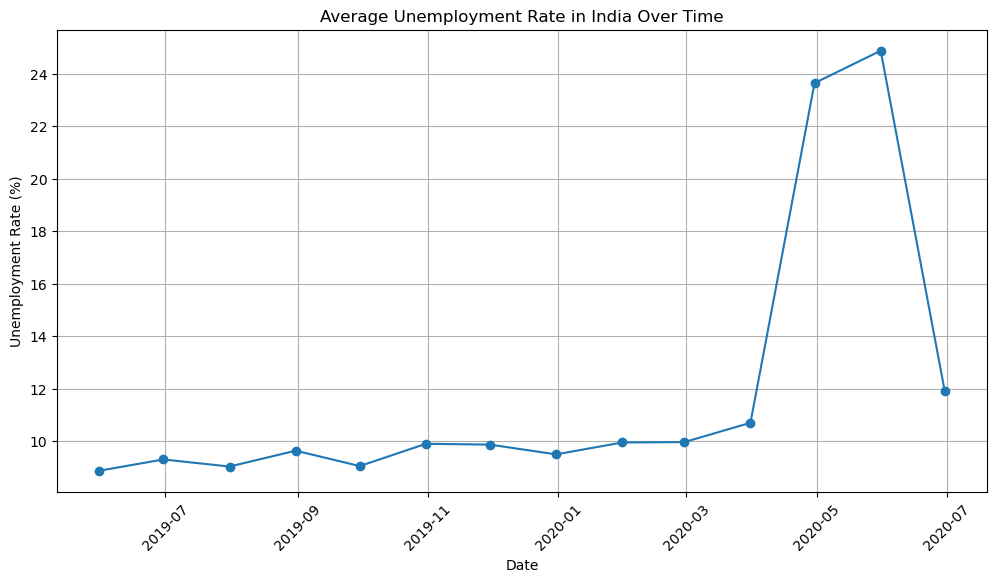

In [29]:
monthly_unemployment = data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_unemployment.index, monthly_unemployment.values, marker='o')

plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# UNEMPLOYMENT RATE BEFORE VS COVID-19 PERIOD

In [30]:
data['Period'] = np.where(
    data['Date'] < '2020-04-01',
    'Before COVID-19',
    'COVID-19 Period'
)

covid_comparison = data.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

print(covid_comparison)

Period
Before COVID-19     9.614864
COVID-19 Period    20.194342
Name: Estimated Unemployment Rate (%), dtype: float64


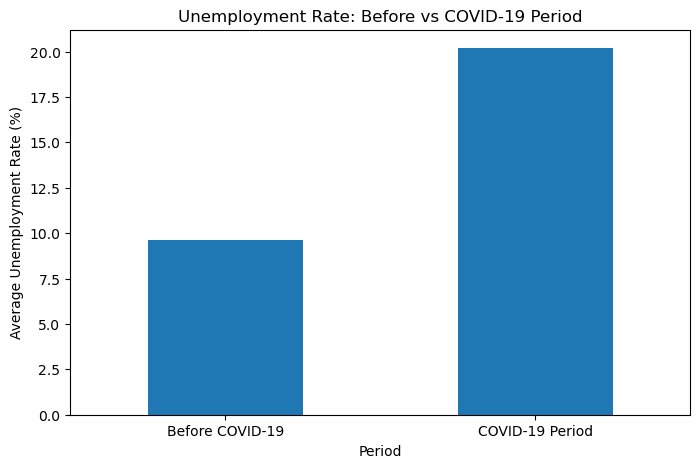

In [31]:
plt.figure(figsize=(8, 5))

covid_comparison.plot(kind='bar')

plt.title('Unemployment Rate: Before vs COVID-19 Period')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [32]:
area_unemployment = data.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

print(area_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


# RURAL VS URBAN ANALYSIS

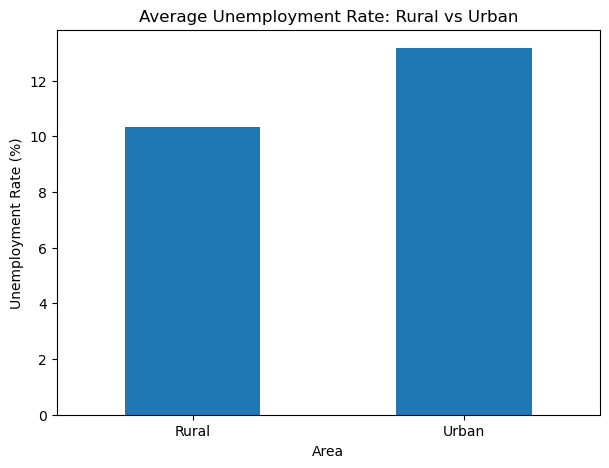

In [33]:
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.show()

# STATE-WISE UNEMPLOYMENT

In [34]:
state_unemployment = (
    data.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print(state_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [35]:
print("Top 10 regions with highest average unemployment:")
print(state_unemployment.head(10))

Top 10 regions with highest average unemployment:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [36]:
print("\nTop 10 regions with lowest average unemployment:")
print(state_unemployment.tail(10))


Top 10 regions with lowest average unemployment:
Region
Maharashtra       7.557500
Andhra Pradesh    7.477143
Madhya Pradesh    7.406429
Sikkim            7.249412
Karnataka         6.676071
Gujarat           6.663929
Uttarakhand       6.582963
Assam             6.428077
Odisha            5.657857
Meghalaya         4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


# VISUALIZE THE HIGHEST UNEMPLOYMENT REGIONS

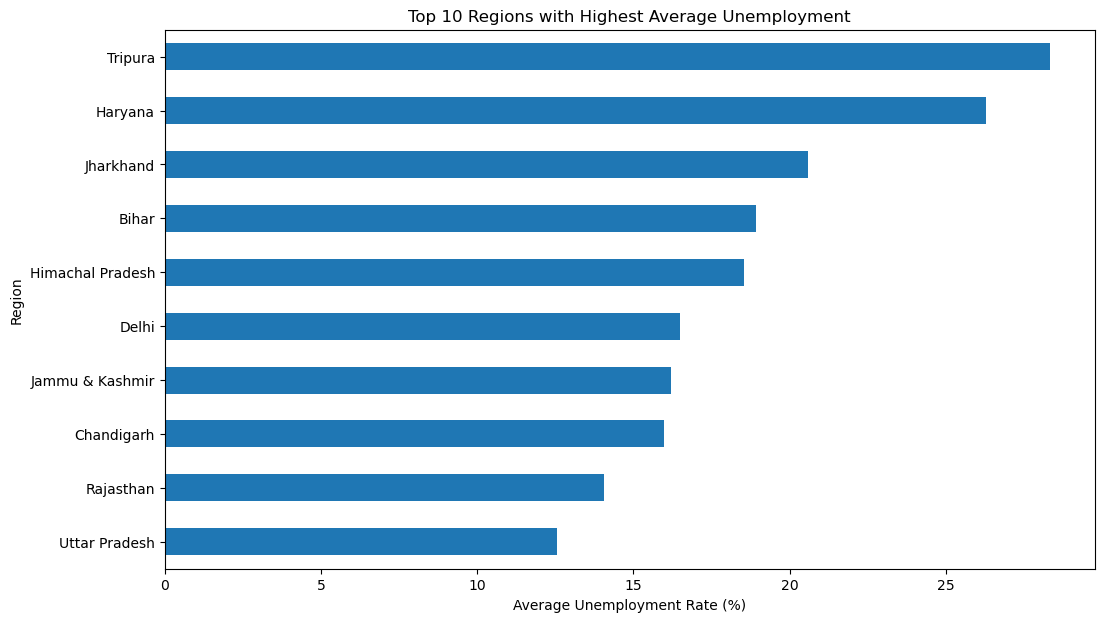

In [37]:
plt.figure(figsize=(12, 7))

state_unemployment.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Regions with Highest Average Unemployment')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.show()

# ANALYZE MAHARASHTRA

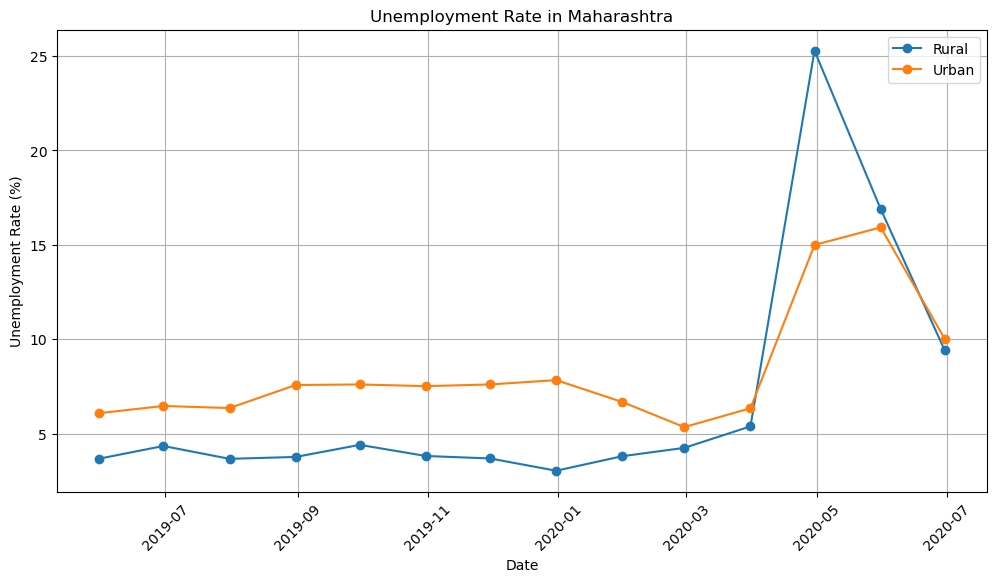

In [39]:
maharashtra = data[data['Region'] == 'Maharashtra']

plt.figure(figsize=(12, 6))

for area in maharashtra['Area'].unique():
    data = maharashtra[maharashtra['Area'] == area]
    plt.plot(
        data['Date'],
        data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=area
    )

plt.title('Unemployment Rate in Maharashtra')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [40]:
monthly_avrage = data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

print(monthly_avrage)

Date
2019-05-31     6.08
2019-06-30     6.46
2019-07-31     6.35
2019-08-31     7.57
2019-09-30     7.60
2019-10-31     7.51
2019-11-30     7.60
2019-12-31     7.83
2020-01-31     6.67
2020-02-29     5.34
2020-03-31     6.34
2020-04-30    14.99
2020-05-31    15.92
2020-06-30    10.01
Name: Estimated Unemployment Rate (%), dtype: float64


# The unemployment dataset was analyzed using Python, Pandas, NumPy, and Matplotlib. The data was cleaned and explored to understand unemployment trends across different regions and areas of India. The analysis shows variations in unemployment rates over time and across regions. Unemployment increased significantly during the COVID-19 period, particularly around April and May 2020. Rural and urban unemployment rates were also compared, showing differences between the two areas. Regional analysis identified areas with relatively high and low unemployment rates. These findings can help policymakers identify regions and periods that may require employment-support programs and economic interventions.